# Figures for thesis

In [1]:
here::i_am("thesis/Thesis_figures.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [2]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood"

In [3]:
io$meta_RNA = file.path(io$basedir, 'results/rna/mapping/sample_metadata_after_mapping.txt.gz')
io$meta_ATAC = file.path(io$basedir, 'results/atac/archR/qc/sample_metadata_update.txt.gz')
io$meta_final = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')
io$sce = io$rna.sce

io$outdir = file.path(io$basedir, '/results/thesis/')
dir.create(outdir, recursive = T)

ERROR: Error in dir.create(outdir, recursive = T): object 'outdir' not found


In [ ]:
plot_umap = function(dt){
    p = ggplot(dt, aes(umap1, umap2)) + 
            theme_void() + 
            coord_fixed() 
    return(p)
    }
    

## Chapter 2

In [ ]:
#cell counts
meta_ATAC = fread(io$meta_ATAC)[doublet_call == F & pass_atacQC == T]
table(meta_ATAC$genotype)

meta_RNA = fread(io$meta_RNA)[doublet_call == F & pass_rnaQC == T]
table(meta_RNA$genotype)

meta_final = fread(io$meta_final)
table(meta_final$genotype)

In [2]:
12398 + 20779 

[1] 33177

In [3]:
12916 + 22209 

[1] 35125

In [4]:
11856 + 19740

[1] 31596

### UMAPs from modalities

In [4]:
meta_RNA = fread(io$meta_RNA)
meta_ATAC = fread(io$meta_ATAC)
meta_final = fread(io$meta_final)

In [5]:
io$UMAP_ATAC = paste0(io$basedir, '/results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_FALSE/batch_correction_None/umap_nfeatures25000_dims20_nneighbour25_mindist0.3.txt.gz')
io$UMAP_RNA = paste0(io$basedir, '/results/rna/dimensionality_reduction/sce/none/umap_features1500_pcs15_neigh25_dist0.3.txt.gz')
io$UMAP_MOFA = paste0(io$basedir, '/results/rna_atac/dimensionality_reduction/mofa/MOFA_umap.txt.gz')

In [154]:
test = opts$sample2day[match(meta_ATAC$sample, names(opts$sample2day))]

In [166]:
UMAP_ATAC = fread(io$UMAP_ATAC) %>% 
    merge(., meta_ATAC, by = 'cell') %>% 
    .[, `:=`(day = as.vector(opts$sample2day[match(sample, names(opts$sample2day))]))] %>% 
    .[genotype == 'wt'] %>% 
    .[,umap1 := umap1 * -1] %>% 
    .[,umap2 := umap2 * -1] %>% 
    merge(., meta_final[,.(cell, celltype_v2)], by = 'cell', all.x = T)
UMAP_RNA = fread(io$UMAP_RNA) %>% 
    setnames(c('umap1', 'umap2', 'cell')) %>%
    merge(., meta_RNA, by = 'cell') %>% 
    .[genotype == 'WT'] %>% 
   merge(., meta_final[,.(cell, celltype_v2)], by = 'cell', all.x = T)
UMAP_MOFA = fread(io$UMAP_MOFA) %>% 
    setnames(c('cell', 'umap1', 'umap2')) %>%
    merge(., meta_final, by = 'cell') %>% 
    .[genotype == 'WT']

In [180]:
atac_day = plot_umap(UMAP_ATAC) + 
    ggrastr::rasterise(dpi = 900, input = geom_point(size = -0.3, aes(color = day))) + 
    scale_color_manual(values = opts$days.colors) + 
    theme(legend.position = 'none')

atac_celltype = plot_umap(UMAP_ATAC) + 
    ggrastr::rasterise(dpi = 900, input = geom_point(size = -0.3, aes(color = celltype_v2))) + 
    scale_color_manual(values = opts$celltype_v2.colors) + 
    theme(legend.position = 'none')

rna_day = plot_umap(UMAP_RNA) + 
    ggrastr::rasterise(dpi = 900, input = geom_point(size = -0.3, aes(color = day))) + 
    scale_color_manual(values = opts$days.colors) + 
    theme(legend.position = 'none')

rna_celltype = plot_umap(UMAP_RNA) + 
    ggrastr::rasterise(dpi = 900, input = geom_point(size = -0.3, aes(color = celltype_v2))) + 
    scale_color_manual(values = opts$celltype_v2.colors) + 
    theme(legend.position = 'none')

mofa_day = plot_umap(UMAP_MOFA) + 
    ggrastr::rasterise(dpi = 900, input = geom_point(size = -0.3, aes(color = day))) + 
    scale_color_manual(values = opts$days.colors) + 
    theme(legend.position = 'none')

mofa_celltype = plot_umap(UMAP_MOFA) + 
    ggrastr::rasterise(dpi = 900, input = geom_point(size = -0.3, aes(color = celltype_v2))) + 
    scale_color_manual(values = opts$celltype_v2.colors) + 
    theme(legend.position = 'none')

In [182]:
p1 = ggarrange(rna_day, rna_celltype, nrow = 1)
p2 = ggarrange(atac_day, atac_celltype, nrow = 1)
p3 = ggarrange(mofa_day, mofa_celltype, nrow = 1)

final = ggarrange(p1, p2, p3, ncol =1)

In [183]:
ggsave(file.path(paste0(io$outdir, 'UMAP_combinations.pdf')), 
       plot = final,
       width = 90, 
       height = 80, 
       units = "mm")

In [178]:
file.path(paste0(io$outdir, 'UMAP_combinations.pdf'))

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood//results/thesis/UMAP_combinations.pdf"

### UMAPs of ChromVAR multiome

In [187]:
library(ArchR)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [184]:
ArchRProject = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [189]:
cisbp = getMatrixFromProject(ArchRProject, useMatrix = 'DeviationMatrix_CISBP', useSeqnames = 'z')

cisbp_silico = getMatrixFromProject(ArchRProject, useMatrix = 'silicoChIP_CISBP_v2', useSeqnames = 'z')

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-19f4a179ef2dcb-Date-2024-09-19_Time-11-57-22.log
If there is an issue, please report to github with logFile!

2024-09-19 11:57:43 : Organizing colData, 0.346 mins elapsed.

2024-09-19 11:57:44 : Organizing rowData, 0.353 mins elapsed.

2024-09-19 11:57:44 : Organizing rowRanges, 0.353 mins elapsed.

2024-09-19 11:57:44 : Organizing Assays (1 of 1), 0.354 mins elapsed.

2024-09-19 11:57:49 : Constructing SummarizedExperiment, 0.437 mins elapsed.

2024-09-19 11:57:49 : Finished Matrix Creation, 0.449 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-19f4a11ea560e6-Date-2024-09-19_Time-11-57-49.log
If there is an issue, please report to github with logFile!

2024-09-19 11:57:59 : Organizing colData, 0.156 mins elapsed.

2024-09-19 11:57:59 : Organizing rowData, 0.166 mins elapsed.

2024-09-19 11:57:59 : Organizing rowRanges, 0.166 mins elapsed.

2024-09-19 11:57:59 : Organizing Assays (1 of 1), 0.166 mins elapsed

In [192]:
gene_expr = load_SingleCellExperiment(io$sce, normalise = T, cells = meta_final$cell)

Loading required package: scuttle



In [194]:
gene_expr

class: SingleCellExperiment 
dim: 32285 31596 
metadata(0):
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(31596): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(12): barcode sample ... pass_rnaQC sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [193]:
UMAP_MOFA = fread(io$UMAP_MOFA) %>% 
    setnames(c('cell', 'umap1', 'umap2')) %>%
    merge(., meta_final, by = 'cell') %>% 
    .[genotype == 'WT']

In [252]:
plot_gene = function(gene){
    UMAP_MOFA$gene = as.vector(logcounts(gene_expr[gene, match(UMAP_MOFA$cell, colnames(gene_expr))]))
    gene_cisbp = rownames(cisbp)[grep(gene, rownames(cisbp))]
    UMAP_MOFA$cisbp = as.vector(assay(cisbp[gene_cisbp, match(UMAP_MOFA$cell, colnames(cisbp))]))
    UMAP_MOFA$cisbp_silico = as.vector(assay(cisbp_silico[str_to_upper(gene), match(UMAP_MOFA$cell, colnames(cisbp_silico))]))
    UMAP_MOFA = UMAP_MOFA[order(gene)]
    p1 = plot_umap(UMAP_MOFA) + 
        ggrastr::rasterise(dpi = 900, geom_point(aes(color = scale(gene)), size = -0.2)) +
        scale_color_gradientn(colors = rainbow(5)) + 
        ggtitle('Expression') + 
        guides(
            colour = guide_colourbar(
                barwidth = 0.5, barheight = 2.5,
                frame.colour = "black", 
                ticks.colour = "black",
                order = 2, 
            )) + 
        theme(legend.position = c(0.1, 0.85),
              legend.title = element_blank(),
              plot.title = element_text(hjust = 0.5))

    UMAP_MOFA = UMAP_MOFA[order(abs(cisbp))]
    p2 = plot_umap(UMAP_MOFA) + 
        ggrastr::rasterise(dpi = 900, geom_point(aes(color = cisbp), size = -0.2)) +
        scale_color_gradientn(colors = rainbow(5)) + 
        ggtitle('Cisbp') + 
        guides(
            colour = guide_colourbar(
                barwidth = 0.5, barheight = 2.5,
                frame.colour = "black", 
                ticks.colour = "black",
                order = 2, 
            )) + 
        theme(legend.position = c(0.1, 0.85),
              legend.title = element_blank(),
              plot.title = element_text(hjust = 0.5))

    UMAP_MOFA = UMAP_MOFA[order(abs(cisbp_silico))]
    p3 = plot_umap(UMAP_MOFA) + 
        ggrastr::rasterise(dpi = 900, geom_point(aes(color = scale(cisbp_silico)), size = -0.2)) +
        scale_color_gradientn(colors = rainbow(5)) + 
        ggtitle('cisbp - in silico') + 
        guides(
            colour = guide_colourbar(
                barwidth = 0.5, barheight = 2.5,
                frame.colour = "black", 
                ticks.colour = "black",
                order = 2, 
            )) + 
        theme(legend.position = c(0.1, 0.85),
              legend.title = element_blank(),
              plot.title = element_text(hjust = 0.5))

    ggarrange(p1, p2, p3, nrow = 1)
}

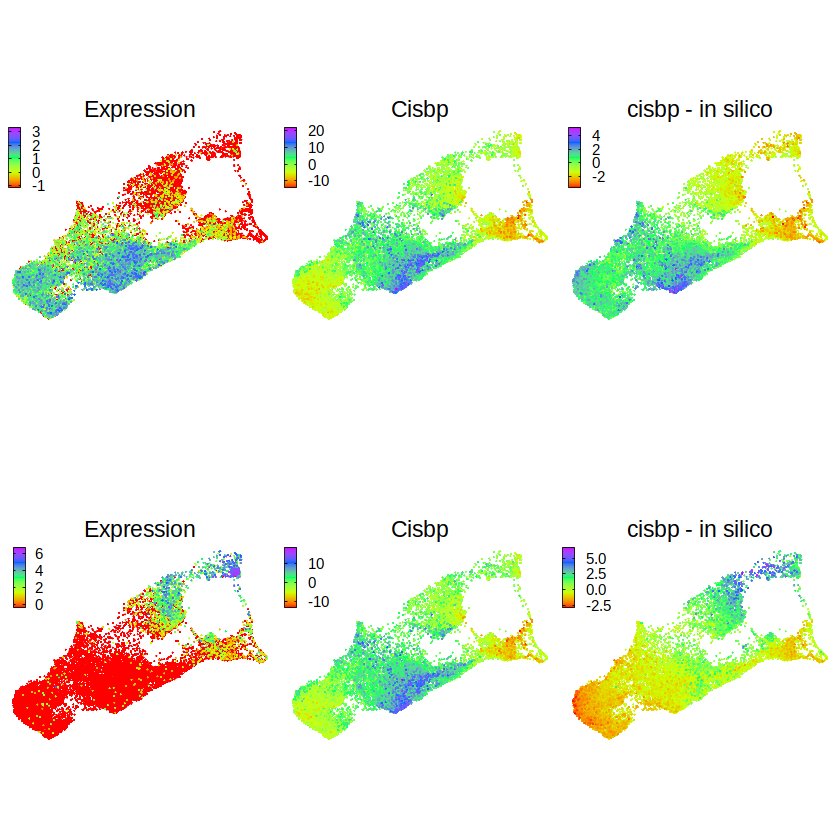

In [253]:
final = ggarrange(plot_gene('Eomes'), 
          plot_gene('Tbx4'), ncol = 1)
final

In [254]:
ggsave(file.path(paste0(io$outdir, 'UMAP_Eomes_Tbx4.pdf')), 
       plot = final,
       width = 150, 
       height = 90, 
       units = "mm")

In [264]:
test = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/PeakCalls/peaks_archR_macs2.bed.gz')
fwrite(test, '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/PeakCalls/peaks_archR_macs2.bed', col.names = F, sep = '\t')

In [263]:
head(test)

V1,V2,V3
<chr>,<int>,<int>
chr1,3003470,3004070
chr1,3035598,3036198
chr1,3062639,3063239
chr1,3191587,3192187
chr1,3263590,3264190
chr1,3482948,3483548


### Genomic regions plot

In [4]:
library(ArchR)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [5]:
ArchRProject = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [33]:
peakSet = as.data.table(ArchRProject@peakSet)

peakSet_stats = peakSet %>% copy() %>%
    .[, prop := .N/nrow(.)*100, by = 'peakType'] %>% 
    unique(by = 'peakType') %>%
    .[, peakType := factor(peakType, levels = c('Promoter', 'Intronic', 'Exonic', 'Distal'))]

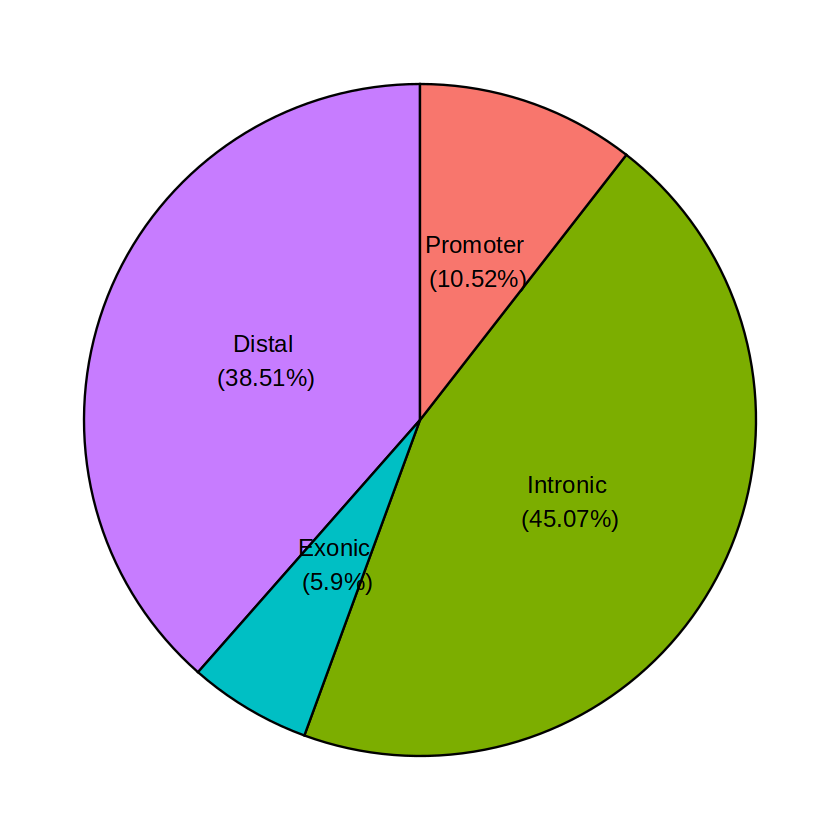

In [44]:
p1 = ggplot(peakSet_stats, aes('', -prop, fill = peakType)) + 
    geom_bar(stat = 'identity', width = 1, color = 'black') + 
    coord_polar(theta = "y", start = 0) +
  theme_void() +  # Remove grid and axis
  geom_text(aes(label = paste0(peakType, '\n (', round(prop, 2), "%)")), 
            position = position_stack(vjust = 0.5), 
            color = "black", size = 5) + 
    theme(legend.position = 'none')
p1

ggsave(file.path(paste0(io$outdir, 'genomic_regions_piechart.pdf')), 
       plot = p1,
       width = 50, 
       height = 50, 
       units = "mm")

## Day - celltype distribution

In [78]:
meta = fread(io$meta_final)

celltype_stats = meta %>% copy() %>% 
    .[genotype == 'WT'] %>%
    .[, Nday := .N, by = 'day'] %>%
    .[, CTprop := .N/Nday * 100, by = c('celltype_v2', 'day')] %>% 
    unique(by = c('celltype_v2', 'day')) %>%
    .[, celltype_fig := opts$celltype_v2_figure[match(celltype_v2, names(opts$celltype_v2_figure))]] %>% 
    .[, celltype_fig := factor(celltype_fig, levels = opts$celltype_v2_figure)] %>%
    .[, day := gsub('D', 'Day ', day)]

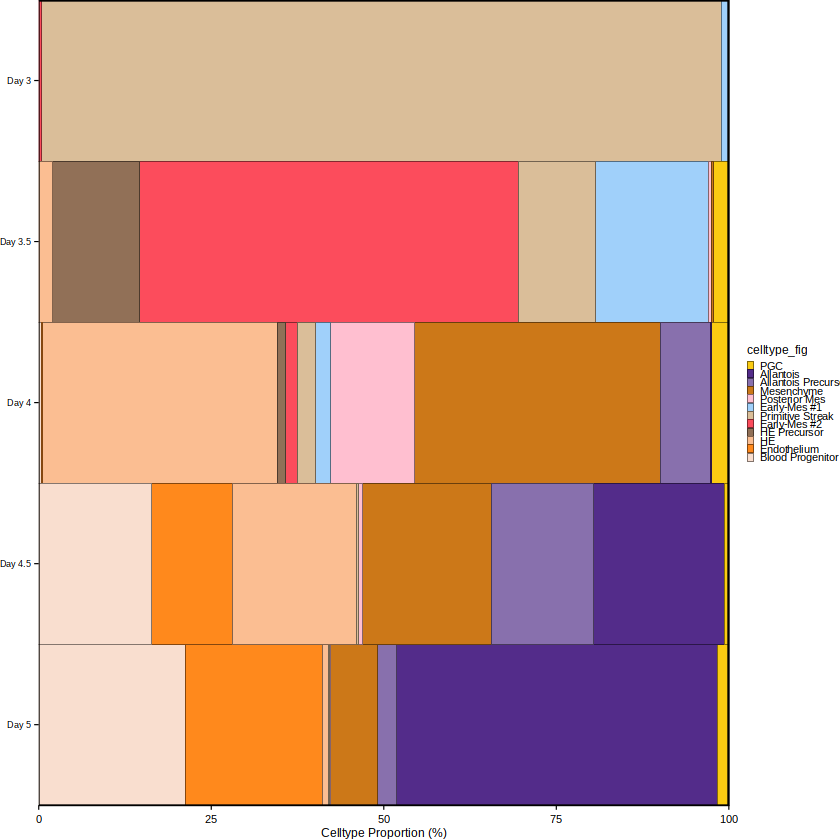

In [92]:
p1 = ggplot(celltype_stats, aes(CTprop, day)) + 
    geom_bar(stat = 'identity', aes(fill = celltype_fig), color = 'black', linewidth = 0.1, width = 1) + 
    scale_fill_manual(values = opts$celltype_v2.colors2) + 
    scale_y_discrete(expand = c(0,0), limits = rev(c('Day 3', 'Day 3.5', 'Day 4', 'Day 4.5', 'Day 5'))) +
    scale_x_continuous(expand = c(0,0)) +
    xlab('Celltype Proportion (%)') + 
    theme_bw() + 
    theme(
        axis.title.y = element_blank(),
        axis.title.x = element_text(size = 7),
        axis.text.x = element_text(angle=0, hjust=0.5, vjust=0, size=6, color = 'black'), 
        axis.text = element_text(size=5, color='black'),
        text = element_text(size=6),
        plot.margin = margin(0, 0, 0, 0),  # Adjust the margin around the plot
        plot.title = element_text(size=7, face='plain', hjust=0.5, vjust = -0.5),
        panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
        panel.background = element_blank(),
        panel.grid.major = element_line(color = 'grey95'),
        axis.line = element_blank(),
        axis.ticks = element_line(linewidth=0.25, color = 'black'),
        legend.title = element_text(size = 7),
        legend.text = element_text(size = 6),
        legend.key.size = unit(1.5, "mm"),
        legend.margin = margin(0,0,0,0)
    )

p1

ggsave(file.path(paste0(io$outdir, 'celltype_proportions_day.pdf')), 
       plot = p1,
       width = 60, 
       height = 40, 
       units = "mm")

### UMAPs from replicates

In [11]:
meta_final = fread(io$meta_final) %>% 
    .[, rep := as.vector(opts$sample2rep[match(sample, names(opts$sample2rep))])]

In [57]:
meta_final$genotype_figure = gsub('KO', 'EOMES-KD', meta_final$genotype)
meta_final$genotype_figure = factor(meta_final$genotype_figure, levels = c("WT", "EOMES-KD"))

meta_final$day_figure = gsub('D', 'Day ', meta_final$day)
meta_final$rep_figure = gsub('rep', 'Replicate ', meta_final$rep)


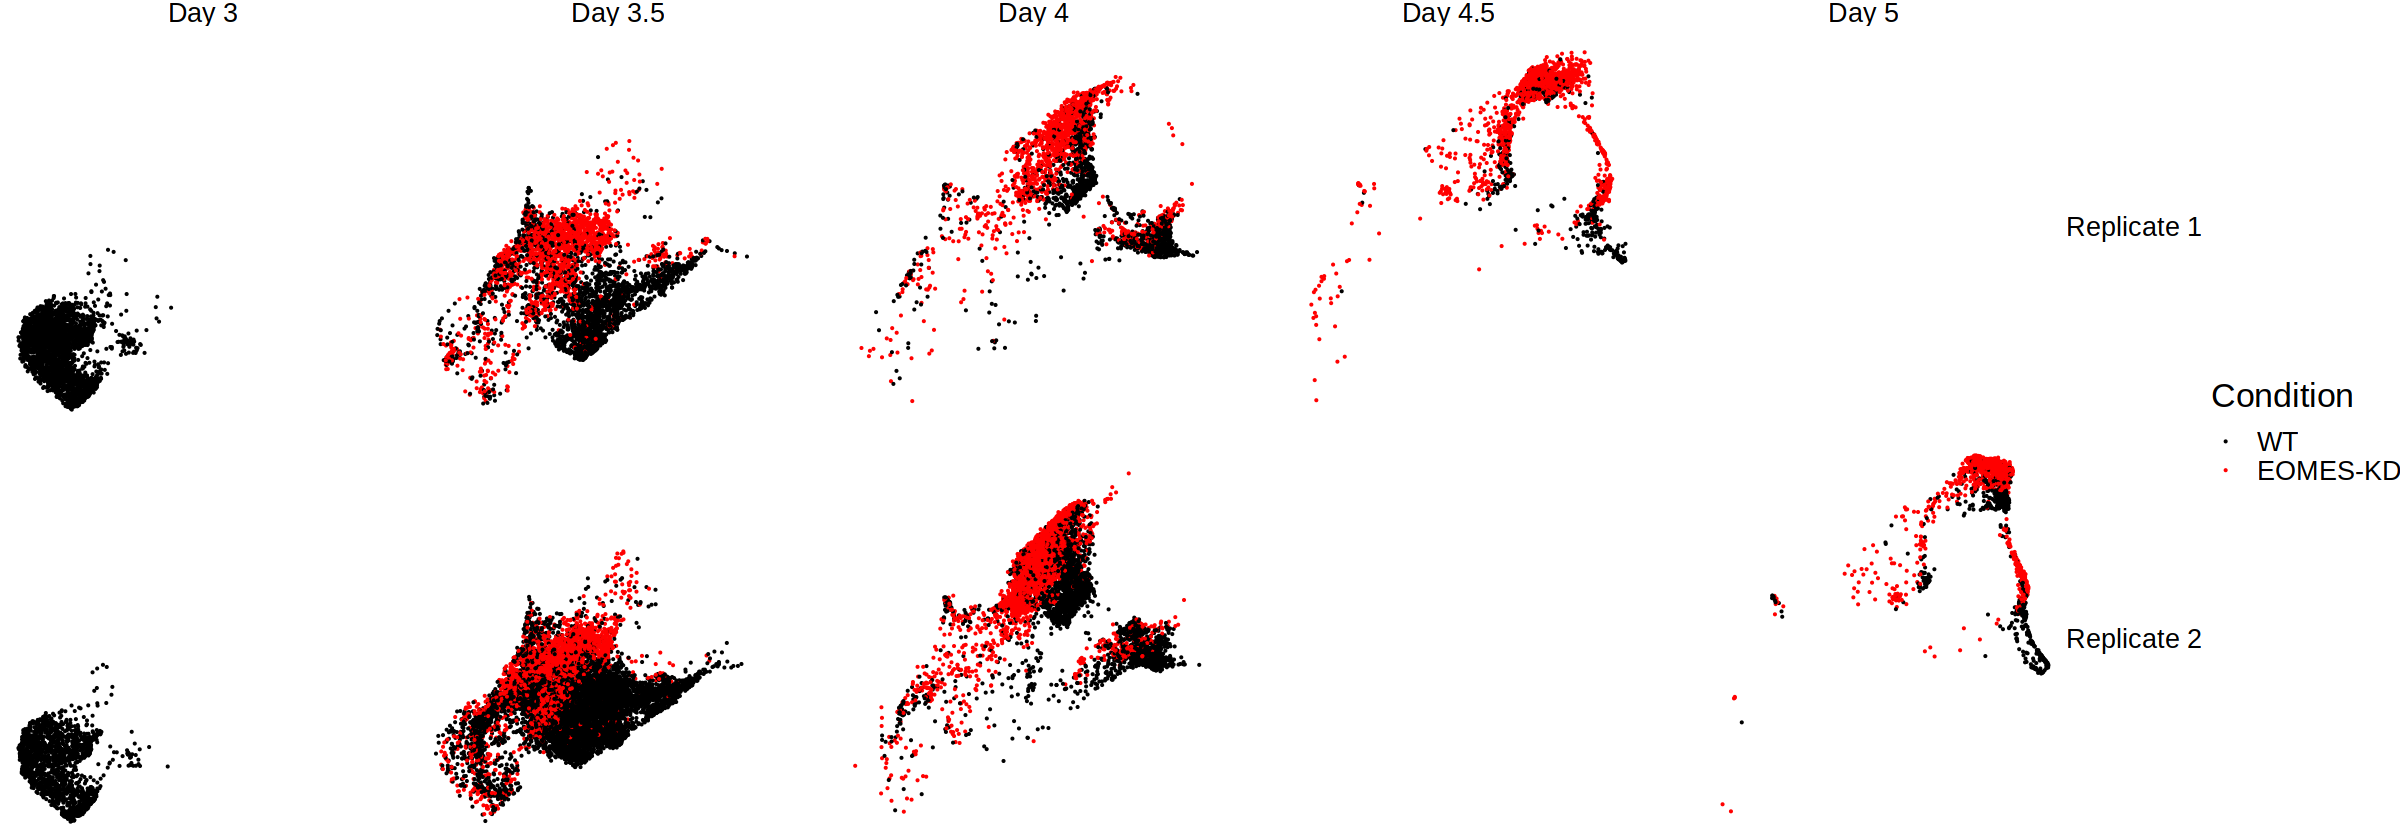

In [58]:
options(repr.plot.width = 20, repr.plot.height = 7)
p1 = ggplot(meta_final[sample(nrow(meta_final))], aes(UMAP1, UMAP2, color = genotype_figure)) + 
    geom_point(size = 0.1) + 
    scale_color_manual(values = c('EOMES-KD' = 'red', 'WT' = 'black'), name = 'Condition') + 
    facet_grid(rows = vars(rep_figure), cols = vars(day_figure)) + 
    theme_void() + 
    theme(text = element_text(size = 20))
p1

In [60]:
ggsave(file.path(paste0(io$outdir, 'umap_replicates.pdf')), 
       plot = p1,
       width = 300, 
       height = 80, 
       units = "mm")